In [24]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## FaIR
from fair import FAIR
from fair.io import read_properties
from fair.interface import initialise, fill
import run_fair

## Helpers
import utils_TF

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Root Relative Squared Error: 0.0002

      Regressors  Parameters             ERR
0        x1(k-2)  9.0000E-01  9.58654026E-01
1         y(k-1)  2.0001E-01  3.81878213E-02
2  x1(k-1)y(k-1)  1.0001E-01  3.15812046E-03
3      x1(k-2)^2  2.5843E-05  4.65127991E-10


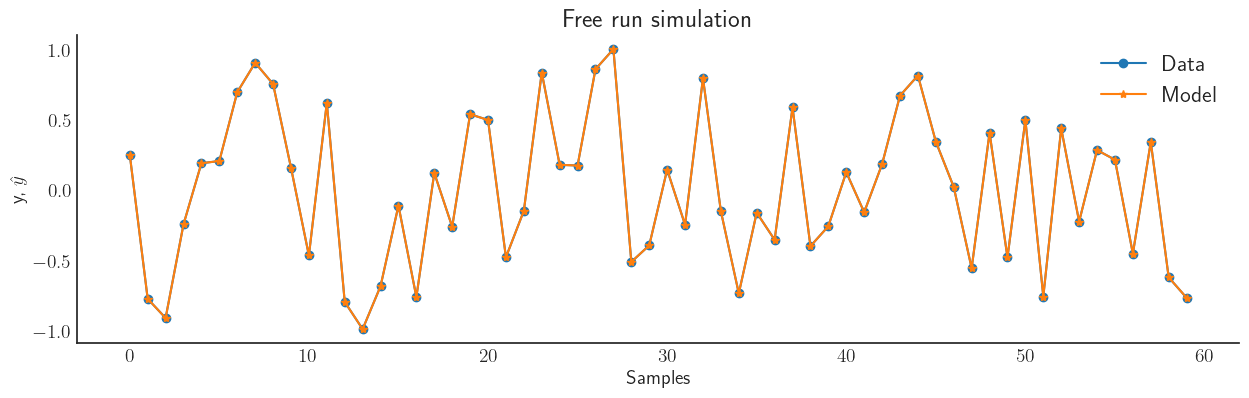

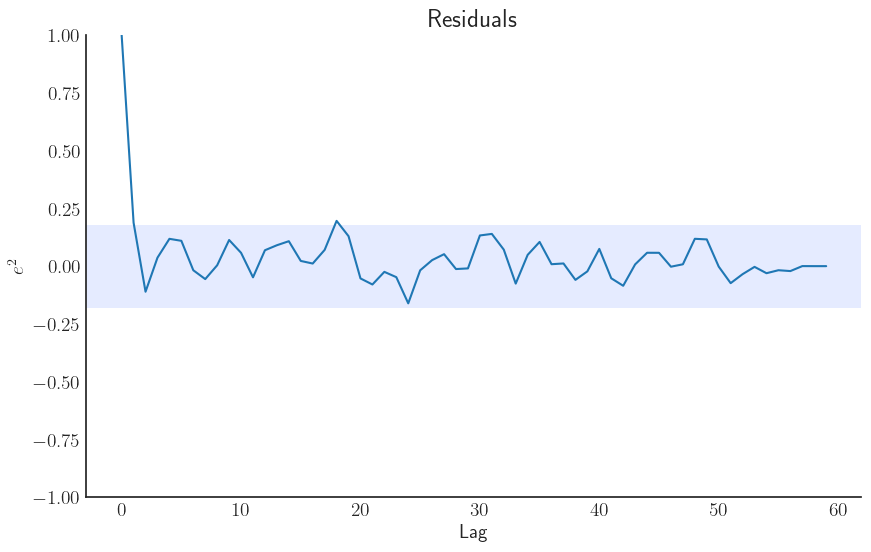

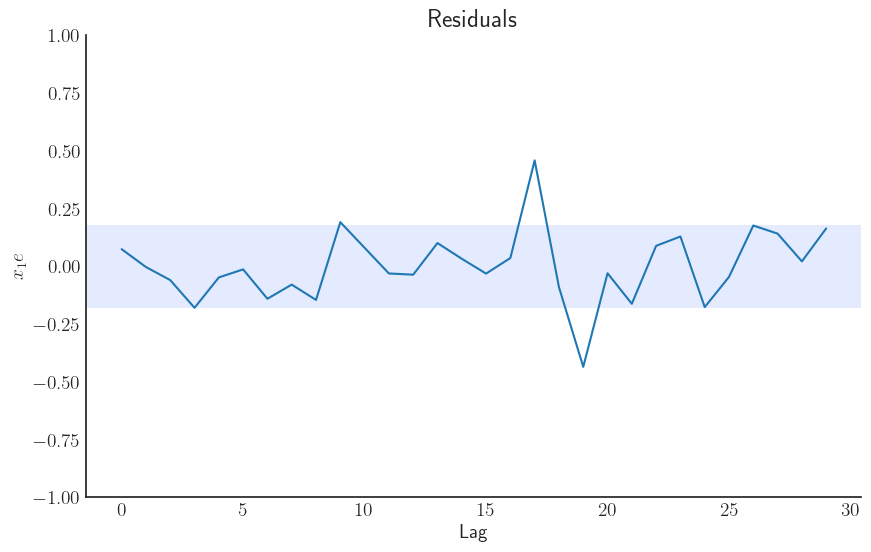

In [22]:
import pandas as pd
import numpy as np  # Import numpy to handle reshaping
from sysidentpy.utils.generate_data import get_siso_data
from sysidentpy.model_structure_selection import FROLS
from sysidentpy.basis_function import Polynomial
from sysidentpy.metrics import root_relative_squared_error
from sysidentpy.utils.display_results import results
from sysidentpy.utils.plotting import plot_results
from sysidentpy.utils.plotting import plot_residues_correlation
from sysidentpy.residues.residues_correlation import (
    compute_residues_autocorrelation,
    compute_cross_correlation,
)

# Generate a dataset from a simulated dynamic system.
x_train, x_valid, y_train, y_valid = get_siso_data(
    n=300,
    colored_noise=False,
    sigma=0.0001,
    train_percentage=80
)

# FIX #2: Reshape the data from 1D vectors to 2D column vectors
x_train = x_train.reshape(-1, 1)
x_valid = x_valid.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_valid = y_valid.reshape(-1, 1)


basis_function = Polynomial(degree=2)

# FIX #1: Enable automatic model selection and define info criteria
# This is the full model definition from the quickstart guide
model = FROLS(
    order_selection=True,
    n_info_values=4,
    extended_least_squares=False,
    ylag=2, xlag=2,
    info_criteria='aic',
    estimator='least_squares',
    basis_function=basis_function
)

# The rest of the code works as expected now
model.fit(X=x_train, y=y_train)
yhat = model.predict(X=x_valid, y=y_valid)

rrse = root_relative_squared_error(y_valid, yhat)
print(f"Root Relative Squared Error: {rrse:.4f}\n")

r = pd.DataFrame(
    results(
        model.final_model, model.theta, model.err,
        model.n_terms, err_precision=8, dtype='sci'
        ),
    columns=['Regressors', 'Parameters', 'ERR'])
print(r)

plt.style.library['seaborn-white'] = plt.style.library['seaborn-v0_8-white']

plot_results(y=y_valid, yhat=yhat, n=1000, figsize=(15, 4))
ee = compute_residues_autocorrelation(y_valid, yhat)
plot_residues_correlation(data=ee, title="Residuals", ylabel="$e^2$")
x1e = compute_cross_correlation(y_valid, yhat, x_valid)
plot_residues_correlation(data=x1e, title="Residuals", ylabel="$x_1e$")

In [50]:
start, stop = 1500, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
response_dict = run_fair.generate_responses(start, stop, n_steps, years, dt, freq_s, nperseg)

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

Running 66 projections in parallel:   0%|          | 0/1001 [00:00<?, ?timesteps/s]

In [67]:
start, stop = 1750, 2500
years = np.arange(start, stop)
n_steps = len(years)
dt = 1
freq_s = 1
nperseg = 250
fair = fair_pulse = run_fair.initialise_fair(start, stop)

co2 = np.linspace(0, 10, n_steps)
nan_force = np.linspace(0, 0, n_steps)

agents = ['CO2','CH4','N2O','Sulfur','BC']
emission_dict = {
  'CO2':co2,
  'CH4':nan_force,
  'N2O':nan_force,
  'Sulfur':nan_force,
  'BC':nan_force
}

t, T_ens, T_mean, ECS = run_fair.run_multi_agent(fair, n_steps, years, agents, emission_dict)

Running 66 projections in parallel:   0%|          | 0/751 [00:00<?, ?timesteps/s]

In [76]:
def ema(x, halflife):
    # simple EMA with half-life in steps; convert to alpha
    import numpy as np
    lam = np.log(2.0) / max(halflife, 1e-6)
    y = np.zeros_like(x, dtype=float)
    for t in range(1, len(x)):
        y[t] = y[t-1] * np.exp(-lam) + (1 - np.exp(-lam)) * x[t]
    return y

In [73]:
x_train, x_valid = response_dict['CO2']['emis'][:500], response_dict['CO2']['emis'][500:]
y_train, y_valid = response_dict['CO2']['temp'][:500], response_dict['CO2']['temp'][500:]

In [77]:
def get_features(x_in):

  halflife_short, halflife_mid, halflife_long = 2, 20, 200
  x1 = ema(x_in, halflife_short)   # ~4 years
  x2 = ema(x_in, halflife_mid)     # ~40 years
  x3 = ema(x_in, halflife_long)    # ~400 years
  x4 = np.cumsum(x_in)

  X = np.column_stack([
      x1, x2, x3, x4,
      np.log1p(np.abs(x1)) * np.sign(x1),
      np.log1p(np.abs(x2)) * np.sign(x2),
      np.log1p(np.abs(x3)) * np.sign(x3),
      np.log1p(np.abs(x4)) * np.sign(x4),
  ])

  return X

In [78]:
X_train = get_features(x_train)
X_valid = get_features(x_valid)

Root Relative Squared Error: 0.9780

   Regressors   Parameters             ERR
0      y(k-1)   9.0019E-01  9.96079823E-01
1     x1(k-1)   8.8999E-04  3.66090239E-03
2      y(k-5)   4.8144E-02  2.35899878E-04
3     x1(k-3)  -1.3672E-04  1.27965006E-05
4     x4(k-3)   2.4667E-05  7.16809576E-06
5    x2(k-12)   1.9467E-05  1.65357477E-06
6     x4(k-6)  -9.7955E-06  4.78445260E-07
7      y(k-4)   2.7553E-02  7.69453249E-07
8      y(k-8)   1.4995E-03  2.64021214E-07
9     x3(k-1)  -5.2577E-04  1.64124016E-07
10   x1(k-12)  -1.9380E-06  3.05801182E-08
11     y(k-7)   8.2331E-03  2.25168262E-08
12     y(k-6)  -1.4856E-02  1.95986279E-08
13     y(k-9)   1.5608E-03  3.57472122E-09
14    x6(k-1)   5.6640E-05  2.17378357E-09
15    y(k-10)   9.1649E-04  6.16448482E-10
16    x7(k-3)  -6.0296E-04  3.49166260E-10
17   x8(k-12)   1.7092E-07  1.96128826E-10
18    x8(k-1)  -1.5442E-07  3.17399632E-11
19    x6(k-3)  -1.4168E-05  4.71352027E-11


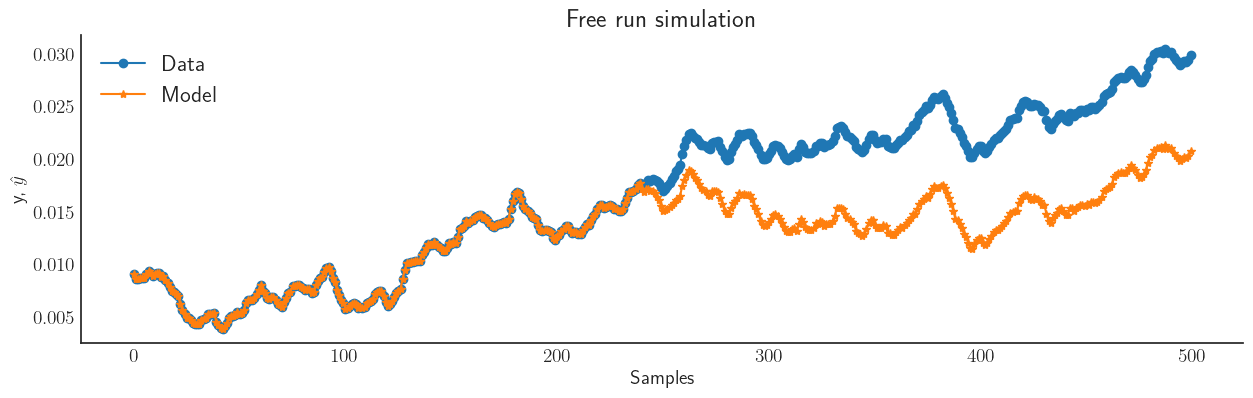

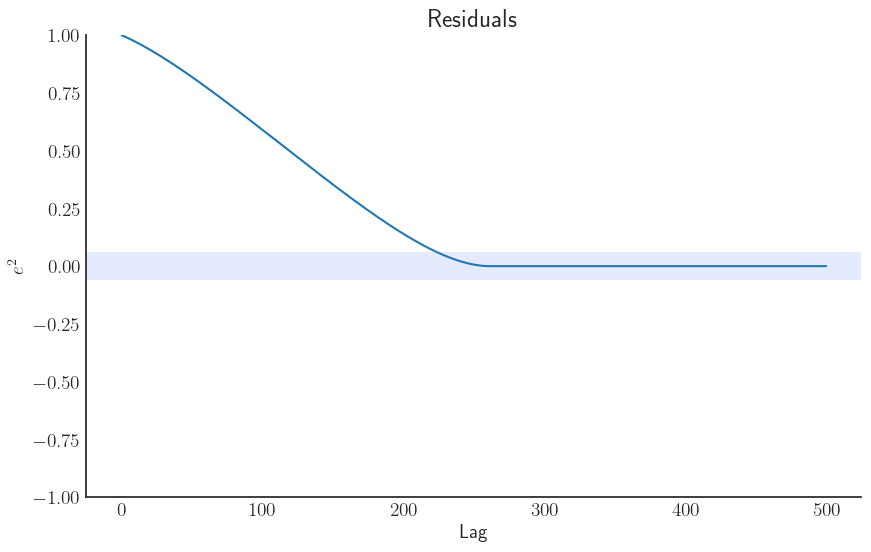

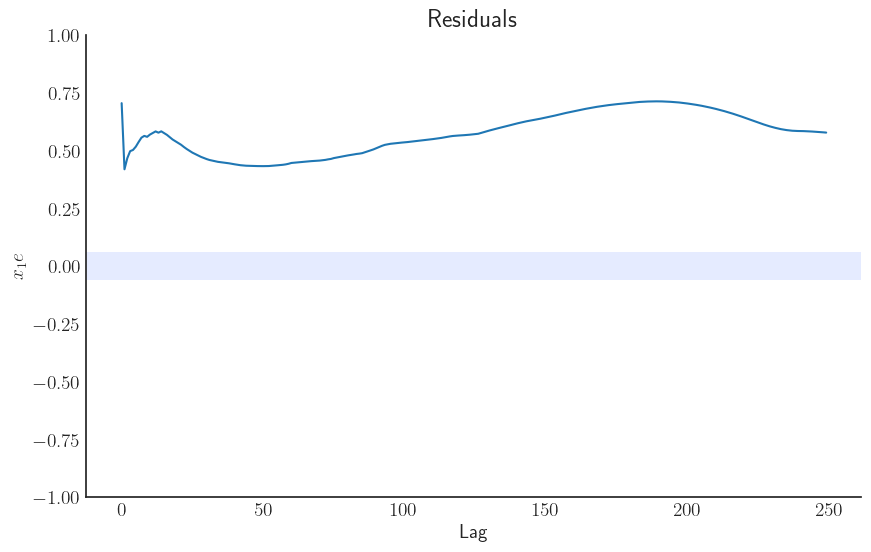

In [95]:
# FIX #2: Reshape the data from 1D vectors to 2D column vectors
#x_train = x_train.reshape(-1, 1)
#x_valid = x_valid.reshape(-1, 1)
y_train = y_train.reshape(-1, 1)
y_valid = y_valid.reshape(-1, 1)


basis_function = Polynomial(degree=1)

lagset = [1, 3, 6, 12, 24, 60, 120, 240]
n_inputs = X_train.shape[1]
xlag = [lagset.copy() for _ in range(n_inputs)]
ylag = 25

# FIX #1: Enable automatic model selection and define info criteria
# This is the full model definition from the quickstart guide
model = FROLS(
    order_selection=True,
    n_info_values=20,                # explore more candidate terms
    info_criteria='bic',             # harsh penalty to avoid overfit
    extended_least_squares=True,     # include MA terms to whiten residuals
    estimator='least_squares',
    ylag=ylag,
    xlag=xlag,
    basis_function=basis_function
)

# The rest of the code works as expected now
model.fit(X=X_train, y=y_train)
yhat = model.predict(X=X_valid, y=y_valid)

rrse = root_relative_squared_error(y_valid, yhat)
print(f"Root Relative Squared Error: {rrse:.4f}\n")

r = pd.DataFrame(
    results(
        model.final_model, model.theta, model.err,
        model.n_terms, err_precision=8, dtype='sci'
        ),
    columns=['Regressors', 'Parameters', 'ERR'])
print(r)

plt.style.library['seaborn-white'] = plt.style.library['seaborn-v0_8-white']

plot_results(y=y_valid, yhat=yhat, n=1000, figsize=(15, 4))
ee = compute_residues_autocorrelation(y_valid, yhat)
plot_residues_correlation(data=ee, title="Residuals", ylabel="$e^2$")
x1e = compute_cross_correlation(y_valid, yhat, X_valid[:,7])
plot_residues_correlation(data=x1e, title="Residuals", ylabel="$x_1e$")